In [1]:
!pip install ccxt==4.3.90 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 175.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 285.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 287.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 165.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 243.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 348.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 226.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 kB 277.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 149.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.6/219.6 kB 218.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
!pip install ccxt pandas requests matplotlib seaborn scipy
!pip install google-generativeai -q


📥 Fetching Fear & Greed data...
   FNG available: 2018-02-01 ~ 2026-03-06 (2952 days)

📥 Fetching BTC/USDT OHLCV from Gate.io...
   Fetched 1000 candles... (last: 2020-09-26)
   Fetched 2000 candles... (last: 2023-06-23)
   Fetched 2987 candles... (last: 2026-03-06)
   Price available: 2018-01-01 ~ 2026-03-06 (2987 days)

✅ Analysis period: 2018-06-04 ~ 2025-11-06 (2712 days)

📊 [BTC-USDT] FNG <-> Backward-Looking Return Correlation
  Window              r     p-value  Result
----------------------------------------------------------------------
  1D            +0.0421      0.0222  ✅ Significant
  5D            +0.3649      0.0000  ✅ Significant
  20D           +0.6386      0.0000  ✅ Significant
  60D           +0.7555      0.0000  ✅ Significant
  120D          +0.6484      0.0000  ✅ Significant

📊 [BTC-USDT] FNG <-> Forward Return Correlation (Predictive Test)
  Window              r     p-value  Result
----------------------------------------------------------------------
  1D       

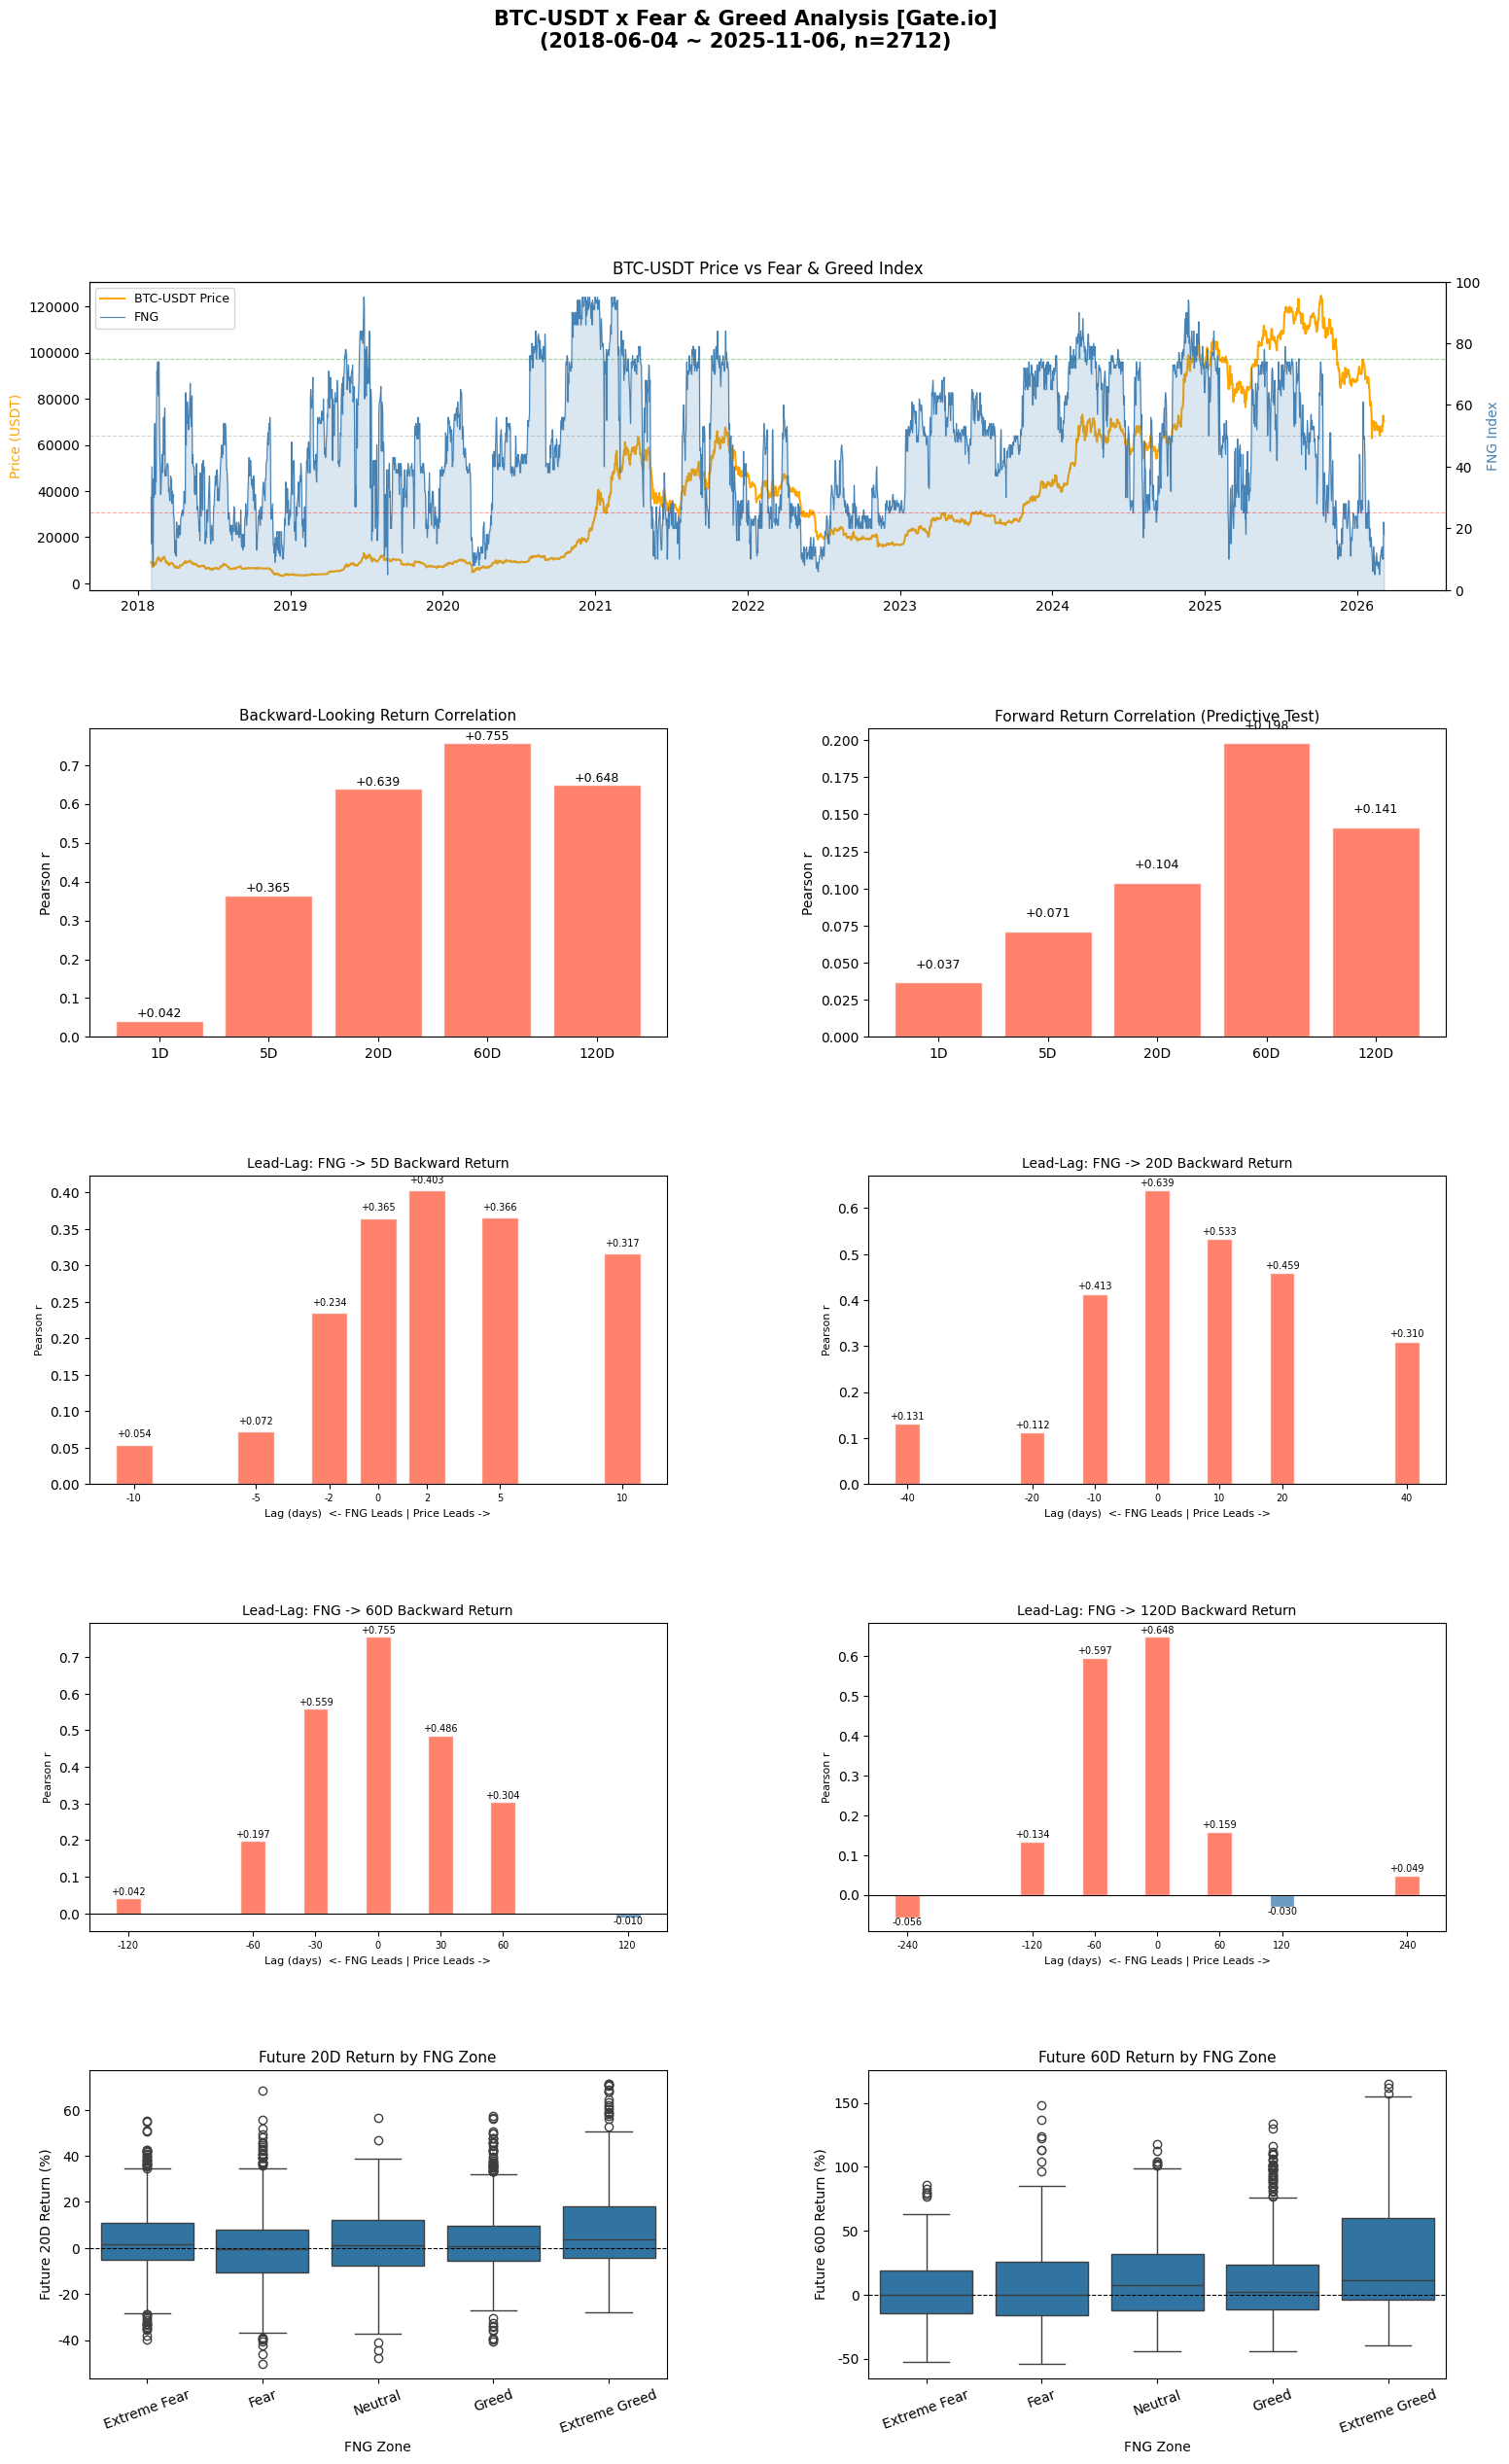


✅ Saved: fng_BTC-USDT_gateio_forward_zone_analysis.png


In [17]:
import ccxt
import pandas as pd
import requests
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
import warnings
import json
import requests as req
from google.colab import userdata

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# =====================
# ⚙️ 설정값
# =====================
SYMBOL = 'BTC/USDT'
START_DATE = '2018-01-01'

PAST_WINDOWS = [1, 5, 20, 60, 120]
FUTURE_WINDOWS = [1, 5, 20, 60, 120]

# =====================
# 1. Fear & Greed
# =====================
print("📥 Fetching Fear & Greed data...")
url = "https://api.alternative.me/fng/?limit=0&format=json"
fng_data = requests.get(url).json()['data']
df_fng = pd.DataFrame(fng_data)

df_fng['timestamp'] = pd.to_numeric(df_fng['timestamp'], errors='coerce')
df_fng['date'] = pd.to_datetime(df_fng['timestamp'], unit='s').dt.date
df_fng['fng_value'] = pd.to_numeric(df_fng['value'], errors='coerce')

df_fng = (
    df_fng[['date', 'fng_value']]
    .dropna()
    .sort_values('date')
    .reset_index(drop=True)
)
df_fng['fng_value'] = df_fng['fng_value'].astype(int)

print(f"   FNG available: {df_fng['date'].min()} ~ {df_fng['date'].max()} ({len(df_fng)} days)")

# =====================
# 2. Gate.io OHLCV
# =====================
print(f"\n📥 Fetching {SYMBOL} OHLCV from Gate.io...")
exchange = ccxt.gateio({'enableRateLimit': True})

if START_DATE is None:
    since_ms = exchange.parse8601('2015-01-01T00:00:00Z')
else:
    since_ms = exchange.parse8601(f'{START_DATE}T00:00:00Z')

all_ohlcv = []
prev_last_ts = None

while True:
    try:
        batch = exchange.fetch_ohlcv(SYMBOL, timeframe='1d', since=since_ms, limit=1000)
    except Exception as e:
        print(f"   ⚠️ Error: {e}")
        break

    if not batch:
        break

    last_ts = batch[-1][0]

    if last_ts == prev_last_ts:
        break

    if all_ohlcv and batch[0][0] == all_ohlcv[-1][0]:
        batch = batch[1:]

    all_ohlcv += batch
    prev_last_ts = last_ts
    since_ms = last_ts + 86400000

    print(f"   Fetched {len(all_ohlcv)} candles... (last: {pd.to_datetime(last_ts, unit='ms').date()})")

    if len(batch) < 1000 or last_ts >= exchange.milliseconds():
        break

df_price = pd.DataFrame(
    all_ohlcv,
    columns=['timestamp', 'open', 'high', 'low', 'close', 'volume']
)
df_price['date'] = pd.to_datetime(df_price['timestamp'], unit='ms').dt.date
df_price = df_price[['date', 'close']].drop_duplicates('date').reset_index(drop=True)

print(f"   Price available: {df_price['date'].min()} ~ {df_price['date'].max()} ({len(df_price)} days)")

# =====================
# 3. 병합 & 수익률 계산
# =====================
df = pd.merge(df_price, df_fng, on='date', how='inner')

# 과거 누적수익률
for w in PAST_WINDOWS:
    df[f'return_{w}d'] = df['close'].pct_change(w) * 100

# 미래 누적수익률 (진짜 예측력 테스트용)
for w in FUTURE_WINDOWS:
    df[f'future_return_{w}d'] = (df['close'].shift(-w) / df['close'] - 1) * 100

coin_name = SYMBOL.replace('/', '-')

# FNG 구간 라벨
def fng_zone_label(v):
    if v <= 25:
        return 'Extreme Fear'
    elif v <= 45:
        return 'Fear'
    elif v <= 55:
        return 'Neutral'
    elif v <= 75:
        return 'Greed'
    else:
        return 'Extreme Greed'

df['fng_zone'] = df['fng_value'].apply(fng_zone_label)
zone_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

df_clean = df.dropna().reset_index(drop=True)

print(f"\n✅ Analysis period: {df_clean['date'].min()} ~ {df_clean['date'].max()} ({len(df_clean)} days)\n")

# =====================
# 4. 과거 수익률 상관관계
# =====================
print("=" * 70)
print(f"📊 [{coin_name}] FNG <-> Backward-Looking Return Correlation")
print("=" * 70)
print(f"  {'Window':<12} {'r':>8}  {'p-value':>10}  Result")
print("-" * 70)

corr_results = []
for w in PAST_WINDOWS:
    col = f'return_{w}d'
    tmp = df[['fng_value', col]].dropna()
    r, p = stats.pearsonr(tmp['fng_value'], tmp[col])
    sig = "✅ Significant" if p < 0.05 else "❌ Not Significant"
    corr_results.append({'window': w, 'r': r, 'p': p})
    print(f"  {str(w)+'D':<12} {r:>+8.4f}  {p:>10.4f}  {sig}")

# =====================
# 5. 미래 수익률 상관관계
# =====================
print("\n" + "=" * 70)
print(f"📊 [{coin_name}] FNG <-> Forward Return Correlation (Predictive Test)")
print("=" * 70)
print(f"  {'Window':<12} {'r':>8}  {'p-value':>10}  Result")
print("-" * 70)

future_corr_results = []
for w in FUTURE_WINDOWS:
    col = f'future_return_{w}d'
    tmp = df[['fng_value', col]].dropna()
    r, p = stats.pearsonr(tmp['fng_value'], tmp[col])
    sig = "✅ Significant" if p < 0.05 else "❌ Not Significant"
    future_corr_results.append({'window': w, 'r': r, 'p': p})
    print(f"  {str(w)+'D':<12} {r:>+8.4f}  {p:>10.4f}  {sig}")

# =====================
# 6. Lead-Lag (과거 수익률 기준)
# =====================
print("\n" + "=" * 70)
print(f"📊 [{coin_name}] Lead-Lag Analysis (FNG -> Backward Returns)")
print("=" * 70)

LAG_WINDOWS = [1, 5, 20, 60, 120]
all_lag_results = {}
best_lag_summary = []

for w in LAG_WINDOWS:
    print(f"\n--- {w}D Return ---")
    print(f"{'Lag':>8}  {'r':>8}  {'p-value':>9}  {'Sig':>4}  Interpretation")
    print("-" * 70)

    max_lag = w * 2
    lags = sorted(set([-max_lag, -w, -max(1, w//2), 0, max(1, w//2), w, max_lag]))

    lag_results = []
    for lag in lags:
        col = f'return_{w}d'
        tmp = df[['fng_value', col]].dropna().reset_index(drop=True)

        if lag < 0:
            x = tmp['fng_value'].iloc[:lag].values
            y = tmp[col].iloc[-lag:].values
            direction = f"FNG leads by {abs(lag)}d"
        elif lag > 0:
            x = tmp['fng_value'].iloc[lag:].values
            y = tmp[col].iloc[:-lag].values
            direction = f"Price leads by {lag}d"
        else:
            x = tmp['fng_value'].values
            y = tmp[col].values
            direction = "Concurrent"

        r, p = stats.pearsonr(x, y)
        sig = "✅" if p < 0.05 else "  "
        lag_results.append({'lag': lag, 'r': r, 'p': p, 'direction': direction})
        print(f"{lag:>8}  {r:>+8.4f}  {p:>9.4f}  {sig:>4}  {direction}")

    df_lag = pd.DataFrame(lag_results)
    best = df_lag.loc[df_lag['r'].abs().idxmax()]
    print(f"📌 Max: lag={int(best['lag'])}d ({best['direction']}), r={best['r']:+.4f}, p={best['p']:.4f}")

    all_lag_results[w] = lag_results
    best_lag_summary.append({
        'window': w,
        'best_lag': int(best['lag']),
        'best_r': float(best['r']),
        'best_p': float(best['p']),
        'direction': best['direction']
    })

# =====================
# 7. FNG 구간별 미래 수익률 분석
# =====================
print("\n" + "=" * 70)
print(f"📊 [{coin_name}] Future Return by FNG Zone")
print("=" * 70)

zone_stats_all = {}

for w in FUTURE_WINDOWS:
    col = f'future_return_{w}d'
    tmp = df[['fng_zone', col]].dropna().copy()

    zone_stats = (
        tmp.groupby('fng_zone')[col]
        .agg(['count', 'mean', 'median', 'std'])
        .reindex(zone_order)
        .reset_index()
    )
    zone_stats_all[w] = zone_stats

    print(f"\n--- Future {w}D Return by FNG Zone ---")
    print(zone_stats.to_string(index=False))

# =====================
# 8. AI 결과 해석 (Gemini -> fallback)
# =====================
print("\n" + "=" * 70)
print(f"🤖 [{coin_name}] AI Interpretation")
print("=" * 70)

GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')

analysis_data = {
    "coin": coin_name,
    "analysis_period": f"{df_clean['date'].min()} ~ {df_clean['date'].max()} ({len(df_clean)} days)",
    "backward_correlation": [
        {
            "window": f"{c['window']}D",
            "r": round(float(c['r']), 4),
            "p": round(float(c['p']), 4),
        }
        for c in corr_results
    ],
    "forward_correlation": [
        {
            "window": f"{c['window']}D",
            "r": round(float(c['r']), 4),
            "p": round(float(c['p']), 4),
        }
        for c in future_corr_results
    ],
    "lead_lag_best": [
        {
            "return_window": f"{s['window']}D",
            "best_lag_days": int(s['best_lag']),
            "r": round(float(s['best_r']), 4),
            "p": round(float(s['best_p']), 4),
            "direction": s['direction']
        }
        for s in best_lag_summary
    ],
    "zone_future_return_mean": {
        f"{w}D": {
            row['fng_zone']: None if pd.isna(row['mean']) else round(float(row['mean']), 4)
            for _, row in zone_stats_all[w].iterrows()
        }
        for w in FUTURE_WINDOWS
    }
}

prompt = f"""
You are a quantitative finance analyst.
Interpret the relationship between Crypto Fear & Greed Index (FNG) and {coin_name}.

Analysis Data:
{json.dumps(analysis_data, indent=2)}

Please explain:
1. Backward-looking correlation pattern
2. Forward-return (predictive) correlation pattern
3. Lead-lag takeaway
4. FNG zone analysis and practical implications
5. One-line overall conclusion

Be specific, data-driven, and cautious about causality.
Write in English, 220-320 words.
"""

MODELS = [
    "gemini-2.5-flash-lite",
    "gemini-2.5-flash",
    "gemini-flash-latest",
    "gemini-2.5-pro",
]

text = None

if GEMINI_API_KEY:
    for model_name in MODELS:
        try:
            url = f"https://generativelanguage.googleapis.com/v1beta/models/{model_name}:generateContent?key={GEMINI_API_KEY}"
            resp = req.post(
                url,
                json={"contents": [{"parts": [{"text": prompt}]}]},
                timeout=30
            )
            result = resp.json()

            if "candidates" in result:
                text = result["candidates"][0]["content"]["parts"][0]["text"]
                print(f"✅ Model used: {model_name}\n")
                print(text)
                break
            else:
                err_msg = result.get("error", {}).get("message", "Unknown error")
                print(f"⚠️ {model_name} failed: {err_msg.splitlines()[0]}")
        except Exception as e:
            print(f"⚠️ {model_name} error: {e}")
else:
    print("⚠️ GOOGLE_API_KEY not found.")

if text is None:
    print("\n⚠️ Gemini unavailable. Using local rule-based interpretation.\n")

    backward_df = pd.DataFrame(corr_results)
    best_backward = backward_df.loc[backward_df['r'].abs().idxmax()]

    forward_df = pd.DataFrame(future_corr_results)
    best_forward = forward_df.loc[forward_df['r'].abs().idxmax()]

    lag_df = pd.DataFrame(best_lag_summary)
    price_lead_count = int((lag_df['best_lag'] > 0).sum())
    fng_lead_count = int((lag_df['best_lag'] < 0).sum())
    concurrent_count = int((lag_df['best_lag'] == 0).sum())

    ef_20 = zone_stats_all[20].set_index('fng_zone')['mean'].to_dict() if 20 in zone_stats_all else {}
    ef_60 = zone_stats_all[60].set_index('fng_zone')['mean'].to_dict() if 60 in zone_stats_all else {}

    fallback_text = f"""
Backward-looking relationship:
FNG shows its strongest contemporaneous relationship with {int(best_backward['window'])}D cumulative return
(r={best_backward['r']:+.4f}, p={best_backward['p']:.4f}).
This suggests that FNG tends to move closely with medium-term price trends.

Forward-looking relationship:
The strongest correlation with future returns is observed at {int(best_forward['window'])}D
(r={best_forward['r']:+.4f}, p={best_forward['p']:.4f}).
This is more relevant for predictive testing than backward-looking returns.

Lead-lag summary:
- Price leads: {price_lead_count}
- FNG leads: {fng_lead_count}
- Concurrent: {concurrent_count}

This pattern suggests that FNG is primarily a coincident sentiment indicator, with some tendency for price to move first and sentiment to follow.

Zone analysis:
For example, mean future 20D returns by zone are:
{json.dumps({k: None if pd.isna(v) else round(float(v), 4) for k, v in ef_20.items()}, indent=2)}

Mean future 60D returns by zone are:
{json.dumps({k: None if pd.isna(v) else round(float(v), 4) for k, v in ef_60.items()}, indent=2)}

Overall conclusion:
FNG is more useful as a sentiment regime / market-state indicator and should be tested carefully as a predictive signal using future-return analysis rather than backward-looking correlation alone.
""".strip()

    print(fallback_text)

# =====================
# 9. 시각화
# =====================
fig = plt.figure(figsize=(18, 28))
fig.suptitle(
    f'{coin_name} x Fear & Greed Analysis [Gate.io]\n'
    f'({df_clean["date"].min()} ~ {df_clean["date"].max()}, n={len(df_clean)})',
    fontsize=15,
    fontweight='bold'
)

gs = fig.add_gridspec(5, 2, hspace=0.45, wspace=0.35)

# --- Chart 1: Price + FNG
ax1 = fig.add_subplot(gs[0, :])
ax2 = ax1.twinx()
ax1.plot(pd.to_datetime(df['date']), df['close'], color='orange', linewidth=1.5, label=f'{coin_name} Price')
ax2.fill_between(pd.to_datetime(df['date']), df['fng_value'], alpha=0.2, color='steelblue')
ax2.plot(pd.to_datetime(df['date']), df['fng_value'], color='steelblue', linewidth=0.8, label='FNG')
for lvl, col in [(25, 'red'), (50, 'gray'), (75, 'green')]:
    ax2.axhline(y=lvl, color=col, linestyle='--', alpha=0.35, linewidth=0.8)
ax1.set_ylabel('Price (USDT)', color='orange')
ax2.set_ylabel('FNG Index', color='steelblue')
ax2.set_ylim(0, 100)
ax1.set_title(f'{coin_name} Price vs Fear & Greed Index', fontsize=12)
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='upper left', fontsize=9)

# --- Chart 2: Backward correlation
ax_corr1 = fig.add_subplot(gs[1, 0])
windows1 = [c['window'] for c in corr_results]
r_vals1 = [c['r'] for c in corr_results]
p_vals1 = [c['p'] for c in corr_results]
colors1 = ['tomato' if p < 0.05 else 'steelblue' for p in p_vals1]
bars1 = ax_corr1.bar([f'{w}D' for w in windows1], r_vals1, color=colors1, alpha=0.8, edgecolor='white')
ax_corr1.axhline(0, color='black', linewidth=0.8)
ax_corr1.set_title('Backward-Looking Return Correlation', fontsize=11)
ax_corr1.set_ylabel('Pearson r')
for bar, r in zip(bars1, r_vals1):
    ax_corr1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if r >= 0 else -0.02),
                  f'{r:+.3f}', ha='center', fontsize=9)

# --- Chart 3: Forward correlation
ax_corr2 = fig.add_subplot(gs[1, 1])
windows2 = [c['window'] for c in future_corr_results]
r_vals2 = [c['r'] for c in future_corr_results]
p_vals2 = [c['p'] for c in future_corr_results]
colors2 = ['tomato' if p < 0.05 else 'steelblue' for p in p_vals2]
bars2 = ax_corr2.bar([f'{w}D' for w in windows2], r_vals2, color=colors2, alpha=0.8, edgecolor='white')
ax_corr2.axhline(0, color='black', linewidth=0.8)
ax_corr2.set_title('Forward Return Correlation (Predictive Test)', fontsize=11)
ax_corr2.set_ylabel('Pearson r')
for bar, r in zip(bars2, r_vals2):
    ax_corr2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if r >= 0 else -0.02),
                  f'{r:+.3f}', ha='center', fontsize=9)

# --- Chart 4~7: Lead-Lag
positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
for idx, w in enumerate([5, 20, 60, 120]):
    row, col = positions[idx]
    ax = fig.add_subplot(gs[row, col])
    df_lag = pd.DataFrame(all_lag_results[w])
    lag_colors = ['tomato' if p < 0.05 else 'steelblue' for p in df_lag['p']]
    bar_width = max(df_lag['lag'].diff().dropna().abs().min() * 0.4, 1.5)
    ax.bar(df_lag['lag'], df_lag['r'], width=bar_width, color=lag_colors, alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Lead-Lag: FNG -> {w}D Backward Return', fontsize=10)
    ax.set_xlabel('Lag (days)  <- FNG Leads | Price Leads ->', fontsize=8)
    ax.set_ylabel('Pearson r', fontsize=8)
    ax.set_xticks(df_lag['lag'].tolist())
    ax.tick_params(axis='x', labelsize=7)
    for _, row_data in df_lag.iterrows():
        ax.text(row_data['lag'], row_data['r'] + (0.01 if row_data['r'] >= 0 else -0.02),
                f"{row_data['r']:+.3f}", ha='center', fontsize=7)

# --- Chart 8: Zone vs future 20D return
ax_zone1 = fig.add_subplot(gs[4, 0])
tmp20 = df[['fng_zone', 'future_return_20d']].dropna().copy()
sns.boxplot(data=tmp20, x='fng_zone', y='future_return_20d', order=zone_order, ax=ax_zone1)
ax_zone1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_zone1.set_title('Future 20D Return by FNG Zone', fontsize=11)
ax_zone1.set_xlabel('FNG Zone')
ax_zone1.set_ylabel('Future 20D Return (%)')
ax_zone1.tick_params(axis='x', rotation=20)

# --- Chart 9: Zone vs future 60D return
ax_zone2 = fig.add_subplot(gs[4, 1])
tmp60 = df[['fng_zone', 'future_return_60d']].dropna().copy()
sns.boxplot(data=tmp60, x='fng_zone', y='future_return_60d', order=zone_order, ax=ax_zone2)
ax_zone2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_zone2.set_title('Future 60D Return by FNG Zone', fontsize=11)
ax_zone2.set_xlabel('FNG Zone')
ax_zone2.set_ylabel('Future 60D Return (%)')
ax_zone2.tick_params(axis='x', rotation=20)

plt.savefig(f'fng_{coin_name}_gateio_forward_zone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved: fng_{coin_name}_gateio_forward_zone_analysis.png")